This is a rewrite based on [3 - Neural Machine Translation by Jointly Learning to Align and Translate - legacy](https://github.com/bentrevett/pytorch-seq2seq/blob/main/legacy/3%20-%20Neural%20Machine%20Translation%20by%20Jointly%20Learning%20to%20Align%20and%20Translate.ipynb)
and [non-legacy version](https://github.com/bentrevett/pytorch-seq2seq/blob/main/3%20-%20Neural%20Machine%20Translation%20by%20Jointly%20Learning%20to%20Align%20and%20Translate.ipynb)

This only summarizes the content above in a way that I can easily refer or revise. Full information, please refer to the given link.


_In previous implementations, our context vector needs to contain all information about the source sentence. This is a form of <u>compression</u> where the first information will eventually be lost if the source sentence is too long._

**Concept**

The model implemented here is avoids this compression via `Attention`.
- First, calculate an attention vector, a, that is the length of the sentence.
- The attention vector has the property that **each element is between 0 and 1**, and the **entire vector sums to 1**.
- Then, calculate a weighted sum of our source sentence hidden states, H, to get a weighted source vector, w.

<center>$w$ = ∑($a_{i}$$h_{i}$)</center>


- We calculate a new weighted source vector every time-step when decoding
- using it as input to our decoder RNN as well as the linear layer to make a prediction.

In [1]:
!pip install datasets evaluate --upgrade

!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 51.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 52.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchtext ; torchtext.disable_torchtext_deprecation_warning()
from torchtext.vocab import build_vocab_from_iterator

import random
import spacy
import numpy as np

import datasets
import evaluate
import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

Load the data.

In [4]:
dataset = datasets.load_dataset("bentrevett/multi30k")
train_data, valid_data, test_data = (
    dataset["train"],
    dataset["validation"],
    dataset["test"],
)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
spacy_de = spacy.load('de_core_news_sm')
spacy_en = spacy.load('en_core_web_sm')

Previously we reversed the source (German) sentence, however in the paper we are implementing they don't do this, so neither will we.

In [6]:
def tokenize_example(example, spacy_en, spacy_de, max_length, lower, sos_token, eos_token):
    en_tokens = [token.text for token in spacy_en.tokenizer(example["en"])][:max_length]
    de_tokens = [token.text for token in spacy_de.tokenizer(example["de"])][:max_length]
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        de_tokens = [token.lower() for token in de_tokens]
    en_tokens = [sos_token] + en_tokens + [eos_token]
    de_tokens = [sos_token] + de_tokens + [eos_token]
    return {"en_tokens": en_tokens, "de_tokens": de_tokens}

In [7]:
max_length = 1_000
lower = True
sos_token = "<sos>"
eos_token = "<eos>"

fn_kwargs = {
    "spacy_en": spacy_en,
    "spacy_de": spacy_de,
    "max_length": max_length,
    "lower": lower,
    "sos_token": sos_token,
    "eos_token": eos_token,
}

train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [8]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"

special_tokens = [
    unk_token,
    pad_token,
    sos_token,
    eos_token,
]

en_vocab = build_vocab_from_iterator(
    train_data["en_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

de_vocab = build_vocab_from_iterator(
    train_data["de_tokens"],
    min_freq=min_freq,
    specials=special_tokens,
)

In [9]:
assert en_vocab[unk_token] == de_vocab[unk_token]
assert en_vocab[pad_token] == de_vocab[pad_token]

unk_index = en_vocab[unk_token]
pad_index = en_vocab[pad_token]

en_vocab.set_default_index(unk_index)
de_vocab.set_default_index(unk_index)

In [10]:
def numericalize_example(example, en_vocab, de_vocab):
    en_ids = en_vocab.lookup_indices(example["en_tokens"])
    de_ids = de_vocab.lookup_indices(example["de_tokens"])
    return {"en_ids": en_ids, "de_ids": de_ids}

In [11]:
fn_kwargs = {"en_vocab": en_vocab, "de_vocab": de_vocab}

train_data = train_data.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numericalize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numericalize_example, fn_kwargs=fn_kwargs)

Map:   0%|          | 0/1014 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [12]:
data_type = "torch"
format_columns = ["en_ids", "de_ids"]

train_data = train_data.with_format(
    type=data_type, columns=format_columns, output_all_columns=True
)

valid_data = valid_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

test_data = test_data.with_format(
    type=data_type,
    columns=format_columns,
    output_all_columns=True,
)

In [13]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_de_ids = [example["de_ids"] for example in batch]
        batch_en_ids = nn.utils.rnn.pad_sequence(batch_en_ids, padding_value=pad_index)
        batch_de_ids = nn.utils.rnn.pad_sequence(batch_de_ids, padding_value=pad_index)
        batch = {
            "en_ids": batch_en_ids,
            "de_ids": batch_de_ids,
        }
        return batch

    return collate_fn

In [14]:
def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    collate_fn = get_collate_fn(pad_index)
    data_loader = torch.utils.data.DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=collate_fn,
        shuffle=shuffle,
    )

    return data_loader

In [15]:
batch_size = 128

train_data_loader = get_data_loader(train_data, batch_size, pad_index, shuffle=True)
valid_data_loader = get_data_loader(valid_data, batch_size, pad_index)
test_data_loader = get_data_loader(test_data, batch_size, pad_index)

##Encoder

New: encoder_hidden_dim and decoder_hidden_dim

- Similar to previous model, we use one layer GRU.
- However, we use _bidirectional RNN_
 - With bidirectional RNN, we have _two RNNs per layer_.
 - A _forward RNN_ going over the embedded sentence from left to right (shown in green below),
 - and a _backward RNN_ going over the embedded sentence from right to left (teal).
- This is done in code via `bidirectional = True`, then pass the embedded sentence to the RNN as before.

- `outputs` is of size **[src len, batch size, hid dim *num directions]**
 - <u>first</u> `hid_dim` elements in the third axis are the hidden states from **top layer forward RNN**.
 - <u>last</u> `hid_dim` elements are hidden states from the **top layer backward** RNN.
- We can think of Third axis as being forward and backward hidden states concatenatied together.

- `hidden` is of size **[n layers * num directions, batch sizem, hid dim]**,  
 - **[-2, :, :]** gives top layer forward RNN hidden state after final time-step (i.e. after it has seen the last word)
 - **[-1, :, :]** gives top layer backward RNN hidden state after the final time-step (i.e. after it has seen the first word)

In [16]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, encoder_hidden_dim, decoder_hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, encoder_hidden_dim, bidirectional=True)
        self.fc = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        hidden = torch.tanh(
            self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
        )
        return outputs, hidden

- As the `Decoder` is not bidirectional, it only needs <u>a single context vector</u> to use as its initial hidden state.
 - To solve this, we concatenate the two context vector together
 - Passing through a linear layer, g
 - apply tanh


Note: The actual paper feed only first backward RNN hidden state through a linear layer.

- As we want our model to loop back over the whole of the source sentence, we return `outputs` (the stacked forward and backward hidden states for every token in the source sentence).
- We also return `hidden` (acts as initial hidden state for `Decoder`).

##Attention Layer

- Input
 - Previous hidden state of decoder, $s_{t-1}$.
 - All stacked forward and backward hidden states from encoder, $H$.
- Output
 - Attention vector, at, that is the length of the source sentence.
 - Each element is between 0 and 1, and entire vector sums to 1.

- This layer takes what is decoded so far, st-1, and all of what have been encoded, H, to produce a vector, at,
- That represents which **<u>words in the source sentence we should pay attention the most</u>** in order to correctly predict the next word to decode, y^t+1.
1. First, we calculate the _energy_ between the previous decoder hidden state and encoder hidden states.
2. As our encoder hidden states are a sequence of _T_ tensors, and our previous decoder hidden state is a single tensor, the first thing we do is `repeat` the previous decoder hidden state _T_ times.
3. Calculate the energy, Et, between them by **concatenating them together** and passing them through a linear layer (`attn`) and a tanh activation function.

<center>$Et$ = $tanh$($attn$($s_{t-1},H$))</center>

**Important!**
- This can be thought of as calculating **<u>how well each encoder hidden state "matches" the previous decoder hidden state</u>**.

- For each example in the batch, we have **[dec hid dem, src len]** tensor.
- We want this to be **[src len]** for each example in the batch as the attention should be over the length of the source sentence.
- This is achieved by multiplying the `energy` by a **[1, dec hid dim]** tensor, $v$.

<center>$̂a$ = $vE_t$</center>

- We can think of $v$ as the weights for a **weighted sum of the energy across all encoder hidden states**.
 - These weights tell us how much we should attend to each token in the source sequence (hence, attention).
- $v$ is not time-dependent, but is used for each time-step of decoding.
- $v$ is implemented as a linear layer without a bias.
- Finally, we ensure attention vector fits the constraints of having all elements between 0 annd 1 and the vector summing to 1 by passing it through a **softmax** layer.
<center>$a_t$ = $softmax( ̂a )$</center>

- **This gives us attention over the source sentence**.


- The graphical equivalent of calculating the first attention vector, where $s_{t-1} = s_0 = z$

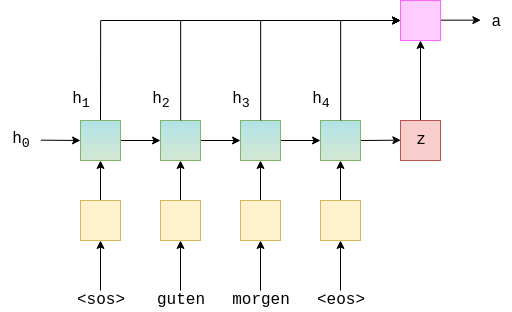

Obtained from https://github.com/bentrevett/pytorch-seq2seq/blob/main/legacy/3%20-%20Neural%20Machine%20Translation%20by%20Jointly%20Learning%20to%20Align%20and%20Translate.ipynb

In [17]:
class Attention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()
        self.attn_fc = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim, decoder_hidden_dim
        )
        self.v_fc = nn.Linear(decoder_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        batch_size = encoder_outputs.shape[1]
        src_length = encoder_outputs.shape[0]
        # repeat decoder hidden state src_length times
        hidden = hidden.unsqueeze(1).repeat(1, src_length, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # hidden = [batch size, src length, decoder hidden dim]
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        energy = torch.tanh(self.attn_fc(torch.cat((hidden, encoder_outputs), dim=2)))
        # energy = [batch size, src length, decoder hidden dim]
        attention = self.v_fc(energy).squeeze(2)
        # attention = [batch size, src length]
        return torch.softmax(attention, dim=1)

##Decoder

- Decoder contains the attention layer, `attention`, which **takes the previous hidden states**, $s_(t-1)$, **all of the encoder hidden states**, $H$, and <u>returns the attention vector, $a_t$</u>.
- Use this attention vector **to create a weighted source vector, $w_t$, denoted by `weighted`**, which is a weighted sum of the encoder hidden states, $H$, at $a_t$, as the weights.
<center>$w_t = a_tH$</center>
- The embedded input word, $d(y_t)$ and $w_t$ being concatenated together.
 <center>$s_t = DecoderGRU(d(y_t), w_t, s_{t-1})$ </center>

- We then pass $d(y_t)$, $w_t$, and $s_t$ through the linear layer, $f$, to make a prediction of the next word in the target sentence, $̂y_{t+1}$.
- This is done by concatenating them all together.
<center>$̂y_{t+1}=f(d(y_t), w_t, s_t)$</center>

The following image shows decoding the first word in an example translation. From https://github.com/bentrevett/pytorch-seq2seq/blob/main/legacy/3%20-%20Neural%20Machine%20Translation%20by%20Jointly%20Learning%20to%20Align%20and%20Translate.ipynb
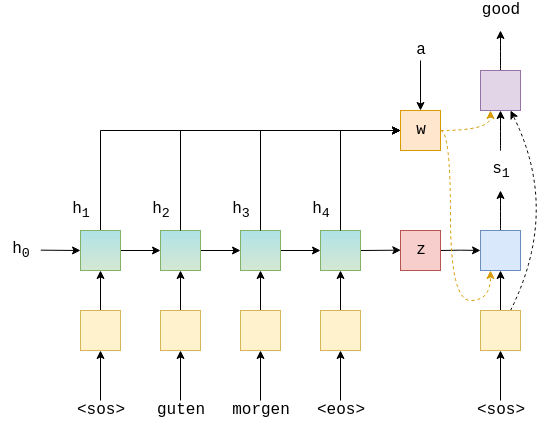

- Green/teal blocks = forward/backward encoder RNN
 - Outputs H
- Red blocks = context vector, $z=h_T=tanh(g(h_T⃑, h_T⃐))$$=tanh(g(z⃑,z⃐))=s_0$
- Blue blocks = decoder RNN
 - Outputs $s_t$
- Purple blocks = linear layer, $f$
 - Outputs $ŷ_{t+1}$ translation
- Ornage blocks = calculation of wieghted sum over $H$ by $a_t$
 - Outputs $w_t$. Not showsn is calculation of $a_t$.

In [18]:
class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        embedding_dim,
        encoder_hidden_dim,
        decoder_hidden_dim,
        dropout,
        attention,
    ):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU((encoder_hidden_dim * 2) + embedding_dim, decoder_hidden_dim)
        self.fc_out = nn.Linear(
            (encoder_hidden_dim * 2) + decoder_hidden_dim + embedding_dim, output_dim
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input = [batch size]
        # hidden = [batch size, decoder hidden dim]
        # encoder_outputs = [src length, batch size, encoder hidden dim * 2]
        input = input.unsqueeze(0)
        # input = [1, batch size]
        embedded = self.dropout(self.embedding(input))
        # embedded = [1, batch size, embedding dim]
        a = self.attention(hidden, encoder_outputs)
        # a = [batch size, src length]
        a = a.unsqueeze(1)
        # a = [batch size, 1, src length]
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        # encoder_outputs = [batch size, src length, encoder hidden dim * 2]
        weighted = torch.bmm(a, encoder_outputs)
        # weighted = [batch size, 1, encoder hidden dim * 2]
        weighted = weighted.permute(1, 0, 2)
        # weighted = [1, batch size, encoder hidden dim * 2]
        rnn_input = torch.cat((embedded, weighted), dim=2)
        # rnn_input = [1, batch size, (encoder hidden dim * 2) + embedding dim]
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        # output = [seq length, batch size, decoder hid dim * n directions]
        # hidden = [n layers * n directions, batch size, decoder hid dim]
        # seq len, n layers and n directions will always be 1 in this decoder, therefore:
        # output = [1, batch size, decoder hidden dim]
        # hidden = [1, batch size, decoder hidden dim]
        # this also means that output == hidden
        assert (output == hidden).all()
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        # prediction = [batch size, output dim]
        return prediction, hidden.squeeze(0), a.squeeze(1)

##Seq2Seq

- This model, encoder RNN and decoder RNN do not have to have the same hidden dimensions, but encoder has to be bidirectional.
- This requirement canc be removed by changing all occurences of `enc_dim*2` to `enc_dim*2 if encoder_is_bidirectional else enc_dim`.

- This seq2seq encapsulator is similar to previous versions except `encoder` returns both final hidden states from forward and backward (because bidirectional).

Steps
1. `outputs` tensor is created to hold all predictions $Ŷ$
2. source sequence, $X$ is fed into encoder to receive $z$ (context vector) and $H$ (encoder bidirectional hidden states)
3. initial decoder hidden state is set to be the `context` vector, $s_0=z=h_T$
4. use a batch of `<sos>` tokens as the first `input`, $y_1$
5. decode within a loop:
 - inser the input token, $y_t$, previous hidden state, $s_{t-1}$, and all encoder outputs, $H$, into the decoder
 - receive a prediction $ŷ_{t+1}$, and a new hidden state, $s_t$
 - decide to teacher-force (for training) or not (not training)  

In [19]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio):
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        # teacher_forcing_ratio is probability to use teacher forcing
        # e.g. if teacher_forcing_ratio is 0.75 we use teacher forcing 75% of the time
        batch_size = src.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        # tensor to store decoder outputs
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size).to(self.device)
        # encoder_outputs is all hidden states of the input sequence, back and forwards
        # hidden is the final forward and backward hidden states, passed through a linear layer
        encoder_outputs, hidden = self.encoder(src)
        # outputs = [src length, batch size, encoder hidden dim * 2]
        # hidden = [batch size, decoder hidden dim]
        # first input to the decoder is the <sos> tokens
        input = trg[0, :]
        for t in range(1, trg_length):
            # insert input token embedding, previous hidden state and all encoder hidden states
            # receive output tensor (predictions) and new hidden state
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            # output = [batch size, output dim]
            # hidden = [n layers, batch size, decoder hidden dim]
            # place predictions in a tensor holding predictions for each token
            outputs[t] = output
            # decide if we are going to use teacher forcing or not
            teacher_force = random.random() < teacher_forcing_ratio
            # get the highest predicted token from our predictions
            top1 = output.argmax(1)
            # if teacher forcing, use actual next token as next input
            # if not, use predicted token
            input = trg[t] if teacher_force else top1
            # input = [batch size]
        return outputs

##Training the model
The rest is similar to previous implementations.

In [20]:
input_dim = len(de_vocab)
output_dim = len(en_vocab)
encoder_embedding_dim = 256 # ENC_EMB_DIM
decoder_embedding_dim = 256 # DEC_EMB_DIM
encoder_hidden_dim = 512 # ENC_HID_DIM
decoder_hidden_dim = 512 # DEC_HID_DIM
encoder_dropout = 0.5 # ENC_DROPOUT
decoder_dropout = 0.5 # DEC_DROPOUT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

attention = Attention(encoder_hidden_dim, decoder_hidden_dim)

encoder = Encoder(
    input_dim,
    encoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    encoder_dropout,
)

decoder = Decoder(
    output_dim,
    decoder_embedding_dim,
    encoder_hidden_dim,
    decoder_hidden_dim,
    decoder_dropout,
    attention
)

model = Seq2Seq(encoder, decoder, device).to(device)

In [21]:
def init_weights(m):
    for name, param in m.named_parameters():
        if "weight" in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7853, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=1536, out_features=512, bias=True)
      (v_fc): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(5893, 256)
    (rnn): GRU(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=5893, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [22]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"The model has {count_parameters(model):,} trainable parameters")

The model has 20,518,405 trainable parameters


In [23]:
optimizer = optim.Adam(model.parameters())

In [24]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)

In [25]:
def train_fn(
    model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device
):
    model.train()
    epoch_loss = 0
    for i, batch in enumerate(data_loader):
        src = batch["de_ids"].to(device)
        trg = batch["en_ids"].to(device)
        # src = [src length, batch size]
        # trg = [trg length, batch size]
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        # output = [trg length, batch size, trg vocab size]
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        # output = [(trg length - 1) * batch size, trg vocab size]
        trg = trg[1:].view(-1)
        # trg = [(trg length - 1) * batch size]
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [26]:
def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for i, batch in enumerate(data_loader):
            src = batch["de_ids"].to(device)
            trg = batch["en_ids"].to(device)
            # src = [src length, batch size]
            # trg = [trg length, batch size]
            output = model(src, trg, 0)  # turn off teacher forcing
            # output = [trg length, batch size, trg vocab size]
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            # output = [(trg length - 1) * batch size, trg vocab size]
            trg = trg[1:].view(-1)
            # trg = [(trg length - 1) * batch size]
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)

In [ ]:
n_epochs = 10
clip = 1.0
teacher_forcing_ratio = 0.5

best_valid_loss = float("inf")

for epoch in tqdm.tqdm(range(n_epochs)):
    train_loss = train_fn(
        model,
        train_data_loader,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device,
    )
    valid_loss = evaluate_fn(
        model,
        valid_data_loader,
        criterion,
        device,
    )
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "tut2-model.pt")
    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {valid_loss:7.3f} | Valid PPL: {np.exp(valid_loss):7.3f}")

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
model.load_state_dict(torch.load("tut2-model.pt"))

test_loss = evaluate_fn(model, test_data_loader, criterion, device)

print(f"| Test Loss: {test_loss:.3f} | Test PPL: {np.exp(test_loss):7.3f} |")

In [ ]:
def translate_sentence(
    sentence,
    model,
    spacy_en,
    spacy_de,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=25,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            de_tokens = [token.text for token in spacy_de.tokenizer(sentence)]
        else:
            de_tokens = [token for token in sentence]
        if lower:
            de_tokens = [token.lower() for token in de_tokens]
        de_tokens = [sos_token] + de_tokens + [eos_token]
        ids = de_vocab.lookup_indices(de_tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        encoder_outputs, hidden = model.encoder(tensor)
        inputs = en_vocab.lookup_indices([sos_token])
        attentions = torch.zeros(max_output_length, 1, len(ids))
        for i in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, attention = model.decoder(
                inputs_tensor, hidden, encoder_outputs
            )
            attentions[i] = attention
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == en_vocab[eos_token]:
                break
        en_tokens = en_vocab.lookup_tokens(inputs)
    return en_tokens, de_tokens, attentions[: len(en_tokens) - 1]

New: plot_attention

TBA

In [ ]:
def plot_attention(sentence, translation, attention):
    fig, ax = plt.subplots(figsize=(10, 10))
    attention = attention.squeeze(1).numpy()
    cax = ax.matshow(attention, cmap="bone")
    ax.set_xticks(ticks=np.arange(len(sentence)), labels=sentence, rotation=90, size=15)
    translation = translation[1:]
    ax.set_yticks(ticks=np.arange(len(translation)), labels=translation, size=15)
    plt.show()
    plt.close()

TEST BEGIN: Attention

In [ ]:
sentence = test_data[0]["de"]
expected_translation = test_data[0]["en"]

sentence, expected_translation

In [ ]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    spacy_en,
    spacy_de,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [ ]:
translation

In [ ]:
sentence_tokens

In [ ]:
plot_attention(sentence_tokens, translation, attention)

Another test

In [ ]:
sentence = "Ein Mann sieht sich einen Film an."

In [ ]:
translation, sentence_tokens, attention = translate_sentence(
    sentence,
    model,
    spacy_en,
    spacy_de,
    en_vocab,
    de_vocab,
    lower,
    sos_token,
    eos_token,
    device,
)

In [ ]:
translation

In [ ]:
plot_attention(sentence_tokens, translation, attention)

TEST END

In [ ]:
translations = [
    translate_sentence(
        example["de"],
        model,
        en_nlp,
        de_nlp,
        en_vocab,
        de_vocab,
        lower,
        sos_token,
        eos_token,
        device,
    )[0]
    for example in tqdm.tqdm(test_data)
]


##Bleu scoring

In [ ]:
bleu = evaluate.load("bleu")

In [ ]:
predictions = [" ".join(translation[1:-1]) for translation in translations]

references = [[example["en"]] for example in test_data]

In [ ]:
def get_tokenizer_fn(nlp, lower):
    def tokenizer_fn(s):
        tokens = [token.text for token in nlp.tokenizer(s)]
        if lower:
            tokens = [token.lower() for token in tokens]
        return tokens

    return tokenizer_fn

In [ ]:
tokenizer_fn = get_tokenizer_fn(spacy_en, lower)

In [ ]:
results = bleu.compute(
    predictions=predictions, references=references, tokenizer=tokenizer_fn
)

In [ ]:
results


Output:
    # The model has 14,219,781 trainable parameters
    # | Test Loss: 3.141 | Test PPL:  23.126 |
    {'bleu': 0.29582040489813916,
    'precisions': [0.607153055396916, 0.3693880688806888, 0.23059626915389742, 0.14807412790697674],
    'brevity_penalty': 1.0,
    'length_ratio': 1.072752335732884,
    'translation_length': 14008,
    'reference_length': 13058}
